In [1]:
from langgraph.graph import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

c:\Users\Yash\Desktop\LangGraph\langgraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [9]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [10]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

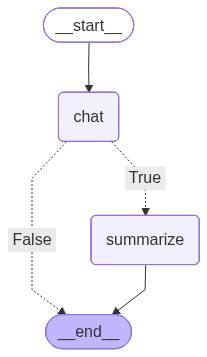

In [11]:
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a176acbe-e029-49d0-8fb1-a39b1664d814')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum Physics is a branch of physics that deals with the behavior of matter an


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a176acbe-e029-49d0-8fb1-a39b1664d814'), AIMessage(content='Quantum Physics is a branch of physics that deals with the behavior of matter and energy at the atomic and subatomic levels. It\'s one of the most successful, yet counter-intuitive, theories in the history of science, fundamentally changing our understanding of reality.\n\nHere\'s a breakdown of its key concepts and implications:\n\n**1. Historical Context:**\nDeveloped in the early 20th century by physicists like Max Planck, Albert Einstein, Niels Bohr, Werner Heisenberg, Erwin Schrödinger, and many others, quantum mechanics emerged because classical physics (Newtonian mechanics and Maxwell\'s electromagnetism) failed to explain phenomena observed at very small scales, such as the stability of atoms, black-body radiation, and the photoelectric effect.\n\n**2. Core Concepts:**\n\n*   **Quantization:** Energy, momentum, angular momentum, and

In [16]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a176acbe-e029-49d0-8fb1-a39b1664d814'), AIMessage(content='Quantum Physics is a branch of physics that deals with the behavior of matter and energy at the atomic and subatomic levels. It\'s one of the most successful, yet counter-intuitive, theories in the history of science, fundamentally changing our understanding of reality.\n\nHere\'s a breakdown of its key concepts and implications:\n\n**1. Historical Context:**\nDeveloped in the early 20th century by physicists like Max Planck, Albert Einstein, Niels Bohr, Werner Heisenberg, Erwin Schrödinger, and many others, quantum mechanics emerged because classical physics (Newtonian mechanics and Maxwell\'s electromagnetism) failed to explain phenomena observed at very small scales, such as the stability of atoms, black-body radiation, and the photoelectric effect.\n\n**2. Core Concepts:**\n\n*   **Quantization:** Energy, momentum, angular momentum, and

In [17]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a176acbe-e029-49d0-8fb1-a39b1664d814'), AIMessage(content='Quantum Physics is a branch of physics that deals with the behavior of matter and energy at the atomic and subatomic levels. It\'s one of the most successful, yet counter-intuitive, theories in the history of science, fundamentally changing our understanding of reality.\n\nHere\'s a breakdown of its key concepts and implications:\n\n**1. Historical Context:**\nDeveloped in the early 20th century by physicists like Max Planck, Albert Einstein, Niels Bohr, Werner Heisenberg, Erwin Schrödinger, and many others, quantum mechanics emerged because classical physics (Newtonian mechanics and Maxwell\'s electromagnetism) failed to explain phenomena observed at very small scales, such as the stability of atoms, black-body radiation, and the photoelectric effect.\n\n**2. Core Concepts:**\n\n*   **Quantization:** Energy, momentum, angular momentum, and

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 34.665197492s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT